# Algortitmo de Deutsche

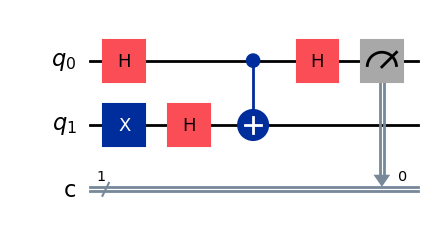

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2,1)
qc.x(1)
qc.h(0)
qc.h(1)

qc.cx(0, 1)

qc.h(0)
qc.measure(0,0)
qc.draw(output="mpl")


In [24]:
from qiskit_aer import Aer
from qiskit import transpile

backend = Aer.get_backend("qasm_simulator")

job = backend.run(transpile(qc, backend), shots=1024)
result = job.result()


counts = result.get_counts()
print(counts)


{'1': 1024}


In [25]:
import numpy as np 
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import Aer
from qiskit import transpile


Uf_bal_0 = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]
])

Uf_bal_1 = np.array([
    [0, 1, 0, 0],
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

Uf_cte_0 = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

Uf_cte_1 = np.array([
    [0, 1, 0, 0],
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]
])

gates = [
         UnitaryGate(Uf_bal_0, label="Ufbal0"),
         UnitaryGate(Uf_bal_1, label="Ufbal1"),
         UnitaryGate(Uf_cte_0, label="Ufcte0"),
         UnitaryGate(Uf_cte_1, label="Ufcte1")
        ]

desc = [
        "balanced identity",
        "balanced conjugate",
        "constant =0",
        "constant =1 ",
       ]

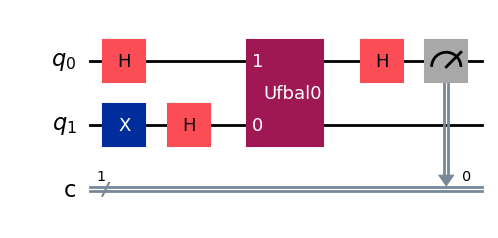

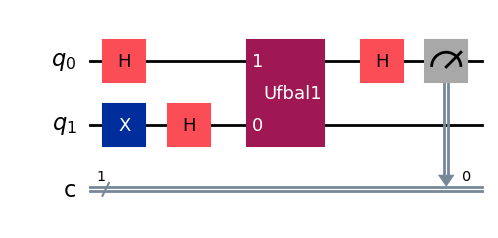

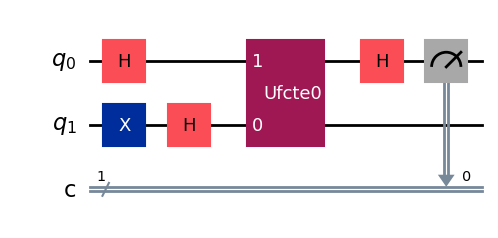

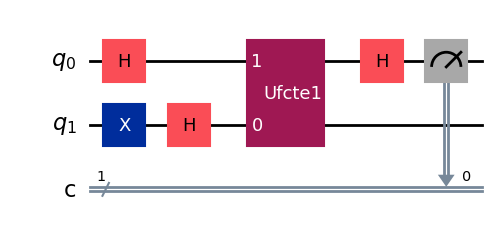

In [26]:
circuits = []
for i in range(4):
    qc = QuantumCircuit(2, 1)
    qc.x(1)
    qc.h(0)
    qc.h(1)
    qc.append(gates[i], [1, 0])
    qc.h(0)
    qc.measure(0, 0)
    display(qc.draw(output="mpl"))
    circuits.append(qc)

In [27]:

for i in range(4):
    backend = Aer.get_backend("qasm_simulator")
    job = backend.run(transpile(circuits[i], backend), shots=1024)
    result = job.result()


    counts = result.get_counts()
    print(desc[i])
    print(counts)


balanced identity
{'1': 1024}
balanced conjugate
{'1': 1024}
constant =0
{'0': 1024}
constant =1 
{'0': 1024}
